In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [2]:
mag_max_eval_range_bright=[[19, 21]]
max_mag_bright= [20.5]
config_bright_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_bright, max_mag=max_mag_bright, mag_max_eval_range=mag_max_eval_range_bright) 

mag_max_eval_range_grey=[[21, 22], [20, 23], [23,25]]
max_mag_grey= [22, 23, 24.5]
config_grey_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_grey, max_mag=max_mag_grey, mag_max_eval_range=mag_max_eval_range_grey)     


mag_max_eval_range_dark=[[23, 24.5], [24.2, 26], [24.2, 26], [24.2, 26]]
max_mag_dark= [24.5, 25, 25.5, 25.5]
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_dark, max_mag=max_mag_dark, mag_max_eval_range=mag_max_eval_range_dark)   


 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
1080000.0
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
6000000.0
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
6000000.0


In [4]:
forecast_bright = _survey_design_science_metrics.Survey_design_science_metrics(config_bright_update, cosmo, 
                                                                   redshift_eval_range =[[0, 1.5]], 
                                                                   mag_max_eval_range=mag_max_eval_range_bright)

Computing forecasts: Survey  Bright  --- tracer:  BG_bright


In [5]:
forecast_grey = _survey_design_science_metrics.Survey_design_science_metrics(config_grey_update, cosmo, 
                                                                   redshift_eval_range =[[0, 2], [0, 2], [0, 2]], 
                                                                   mag_max_eval_range=mag_max_eval_range_grey)

Computing forecasts: Survey  Grey  --- tracer:  BG_faint
Computing forecasts: Survey  Grey  --- tracer:  LRG
Computing forecasts: Survey  Grey  --- tracer:  ELG


In [6]:
forecast_dark = _survey_design_science_metrics.Survey_design_science_metrics(config_dark_update, cosmo, 
                                                                   redshift_eval_range =[[0, 4], [2, 4.5], [2.5, 5], [4, 6]], 
                                                                   mag_max_eval_range=mag_max_eval_range_dark)

Computing forecasts: Survey  Dark  --- tracer:  QSO
Computing forecasts: Survey  Dark  --- tracer:  LBGu
Computing forecasts: Survey  Dark  --- tracer:  LBGg
Computing forecasts: Survey  Dark  --- tracer:  LBGr


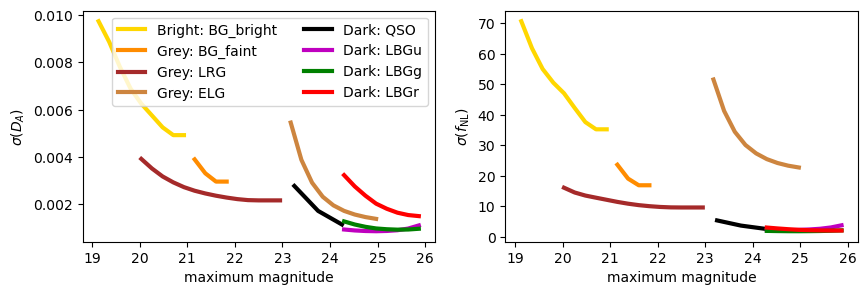

In [7]:
plt.figure(figsize=(10,3))

for forecast, config in zip([forecast_bright, forecast_grey, forecast_dark], [config_bright_update, config_grey_update, config_dark_update]):
    for i,tracer in enumerate(config['tracers']):
        plt.subplot(121)
        plt.plot(forecast[tracer+'_mag_max_eval'], forecast[tracer+'_sigma_Da_eff'] , color = config['color'][i], label = config['survey_type'] + ': '+tracer, lw=3)
        #plt.yscale('log')
        plt.legend(ncols=2)
        plt.ylabel(r'$\sigma(D_A)$', fontsize=10)
        plt.xlabel('maximum magnitude', fontsize=10)
        #plt.yscale('log')
        plt.subplot(122)
        plt.plot(forecast[tracer+'_mag_max_eval'], forecast[tracer+'_sigma_fnl_eff'] , color = config['color'][i], lw=3)
        #plt.yscale('log')

        plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=10)
        plt.xlabel('maximum magnitude', fontsize=10)
        #plt.yscale('log')


In [8]:
Informations_bright = _survey_design_science_metrics.build_total_survey_information_metrics(config_bright_update, forecast_bright)
Informations_grey = _survey_design_science_metrics.build_total_survey_information_metrics(config_grey_update, forecast_grey)
Informations_dark = _survey_design_science_metrics.build_total_survey_information_metrics(config_dark_update, forecast_dark)

In [9]:
def best_idx(FoM): return np.unravel_index( np.argmax(FoM), FoM.shape )

In [10]:
#build FoM
FoM_bright = 30**2*Informations_bright['total_survey_fisher_information_fnl'] + 0.005**2 * Informations_bright['total_survey_fisher_information_Da']
FoM_grey = 10**2*Informations_grey['total_survey_fisher_information_fnl'] + 0.001**2 * Informations_grey['total_survey_fisher_information_Da']
FoM_dark = 1.5**2*Informations_dark['total_survey_fisher_information_fnl'] + 0.001**2 * Informations_dark['total_survey_fisher_information_Da']

In [11]:
def best_idx(FoM): return np.unravel_index( np.argmax(FoM), FoM.shape )
for FoM, config, forecast, informations in zip([FoM_bright, FoM_grey, FoM_dark], 
                                                 [config_bright_update, config_grey_update, config_dark_update], 
                                                 [forecast_bright, forecast_grey, forecast_dark],
                                                 [Informations_bright, Informations_grey, Informations_dark]):
    best_mags = {}
    idx = best_idx(FoM)
    for i, tracer in enumerate(config['tracers']):
        best_mags[tracer] = forecast[tracer + '_mag_max_eval'][idx[i]]
    best_mags['total_survey_time'] = informations['total_survey_time'][idx]
    print(best_mags)

{'BG_bright': np.float64(20.70408163265306), 'total_survey_time': np.float64(0.009942681865632633)}
{'BG_faint': np.float64(21.60204081632653), 'LRG': np.float64(22.5), 'ELG': np.float64(24.96938775510204), 'total_survey_time': np.float64(0.4420753610882374)}
{'QSO': np.float64(24.25), 'LBGu': np.float64(24.744897959183675), 'LBGg': np.float64(25.418367346938776), 'LBGr': np.float64(25.86734693877551), 'total_survey_time': np.float64(0.5059528337482162)}


In [100]:
# plt.title('Dark Time Survey Design')
# plt.scatter(Information_fnl.flatten()**(-0.5), 1e4*Information_Da.flatten()**(-0.5), c = total_time.flatten(), 
#             vmin=0.5,
#             vmax =3, cmap='spring', marker='o', s=40, label = 'Dark Time survey designs')
# plt.ylabel(r'$\sigma(D_A)\times 10^4$', fontsize=15)
# plt.xlabel(r'total $\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
# cbar = plt.colorbar()
# plt.ylim(5, 6)

# plt.xlim(1, 1.3)

# sigma_Da_target = 0.0006
# sigma_fnl_target = 1.1

# FoM_all = (sigma_fnl_target **2 * Information_fnl + sigma_Da_target **2 * Information_Da)
# FoM_fnl = sigma_fnl_target **2 * Information_fnl
# FoM_Da = sigma_Da_target **2 * Information_Da

# plt.scatter(1/Information_fnl[best_idx(FoM_Da)]**.5, 1e4/Information_Da[best_idx(FoM_Da)]**.5, marker='*', color='b', s=300, edgecolors='k', label = r'Optimizing $D_A$ from BAO scales')
# plt.scatter(1/Information_fnl[best_idx(FoM_fnl)]**.5,1e4/Information_Da[best_idx(FoM_fnl)]**.5, marker='s', color='m', s=200, edgecolors='k',label = r'Optimizing $f_{\rm NL}^{\rm loc}$ from large-scale PS')
# plt.scatter(1/Information_fnl[best_idx(FoM_all)]**.5, 1e4/Information_Da[best_idx(FoM_all)]**.5, marker='p', color='g', s=300, edgecolors='k',label = 'Combined')
# cbar.set_label(r'Survey Calendar Time (years)', fontsize=20)
# plt.legend(loc='upper left')